# Import Modules

In [11]:
# DataFrame Modules
import pyranges as pr
import pandas as pd
import numpy as np
from tqdm import tqdm

# Plotting Modules
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Stats & ML Modules
import math
import statsmodels.api as sm
import statsmodels.formula.api as smf
from itertools import combinations
from scipy.spatial.distance import jensenshannon
from statsmodels.stats.multitest import multipletests
from scipy.stats import anderson_ksamp, fisher_exact, permutation_test

# Housekeeping Modules
import re
import time
import requests

# set pandas to display all columns and rows when viewing datasets
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Allow inline plotting
%matplotlib inline

In [3]:
# Access pLDDT scores
alphafold = pd.read_parquet('/slade/home/mr935/data/foldx_data.parquet')

In [3]:
alphafold.head()

,uniprot_accession,uniprot_position,alphafold_fragment_id,alphafold_fragment_position,wild_type,mutated_type,foldx_ddg,plddt
0,A0A075B6S0,1,F1,1,N,A,-0.001835,56.9
1,A0A075B6S0,1,F1,1,N,C,-0.011188,56.9
2,A0A075B6S0,1,F1,1,N,D,-0.041779,56.9
3,A0A075B6S0,1,F1,1,N,E,-0.024084,56.9
4,A0A075B6S0,1,F1,1,N,F,0.324027,56.9


In [4]:
clean_mane = pd.read_parquet('biobank_work/parquets/clean_mane.parquet', engine='pyarrow')

In [5]:
# Get the uniprot accession IDs for each gene
uniprot = pd.read_csv('/slade/home/mr935/data/uniprot_ids.tsv', sep='\t', index_col=False)

In [6]:
clean_mane = clean_mane.merge(
    uniprot,
    left_on='SYMBOL',
    right_on='Approved symbol',
    how='left'
)

In [13]:
clean_mane.sample()

,variantID,Gene,SYMBOL,Strand,Max_SpliceAI_Score,Max_SpliceAI_Column,Max_SpliceAI_Position,Variant_Canonical_Splice_Distance,Feature,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,CCDS,SWISSPROT,UNIPROT_ISOFORM,GENE_PHENO,SIFT,PolyPhen,EXON,HGVSc,HGVSp,MAX_AF,MAX_AF_POPS,CLIN_SIG,CADD_PHRED,CADD_RAW,REVEL,am_class,am_pathogenicity,EVE_CLASS,EVE_SCORE,PrimateAI,lof.oe,lof.pLI,lof.oe_ci.upper,high_pLI,SpliceAI_DS_AG,SpliceAI_DS_AL,SpliceAI_DS_DG,SpliceAI_DS_DL,SpliceAI_DP_AG,SpliceAI_DP_AL,SpliceAI_DP_DG,SpliceAI_DP_DL,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,Approved symbol,Approved name,UniProt ID(supplied by UniProt)
7506752,chr12-95956943-G-C,ENSG00000139344,AMDHD1,+,0.02,SpliceAI_DS_AG,-258.0,19,ENST00000266736,missense_variant,636,568,190,G/R,Ggg/Cgg,"rs1447535570,COSV57139184",MODERATE,CCDS9057.1,Q96NU7.156,None,NaN,deleterious(0),probably_damaging(0.999),4/9,ENST00000266736.7:c.568G>C,ENSP00000266736.2:p.Gly190Arg,0.000018,gnomADe_NFE,None,30.0,4.345982,0.779,likely_pathogenic,0.9495,None,NaN,0.768411,1.046,2.395700e-13,1.381,False,0.02,0.0,0.0,0.0,-258.0,111.0,19.0,275.0,0.000008,0.0,0.0,0.0,0.0,0.0,0.000018,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AMDHD1,amidohydrolase domain containing 1,Q96NU7


In [7]:
# Create separate Missense/Synonymous Consequence Column
clean_mane.rename(columns={'Consequence': 'VEP_Consequence'}, inplace=True)
clean_mane['Consequence'] = clean_mane['VEP_Consequence'].apply(lambda row: 'missense' if 'missense' in row else 'synonymous')

In [8]:
missense = clean_mane[clean_mane['Consequence'] == 'missense'].copy()

In [9]:
missense['wild_type'] = missense['Amino_acids'].str.split('/').str[0]
missense['mutated_type'] = missense['Amino_acids'].str.split('/').str[1]

In [10]:
missense = missense[~missense['UniProt ID(supplied by UniProt)'].isna()]

In [20]:
len(missense)

8069338

In [21]:
# Number of variants with missing UniProt IDs
8323258 - 8069338

253920

In [24]:
alphafold.sample()

,uniprot_accession,uniprot_position,alphafold_fragment_id,alphafold_fragment_position,wild_type,mutated_type,foldx_ddg,plddt
188719579,Q86UQ4,4365,F11,2365,D,L,-2.88441,62.03


In [11]:
missense = missense.merge(
    alphafold[['uniprot_accession', 'uniprot_position',
             'wild_type', 'mutated_type', 'foldx_ddg', 'plddt']],
    left_on=['UniProt ID(supplied by UniProt)', 'Protein_position',
             'wild_type', 'mutated_type'],
    right_on=['uniprot_accession', 'uniprot_position',
              'wild_type', 'mutated_type'],
    how='left'
)

In [38]:
missense.sample()

,variantID,Gene,SYMBOL,Strand,Max_SpliceAI_Score,Max_SpliceAI_Column,Max_SpliceAI_Position,Variant_Canonical_Splice_Distance,Feature,VEP_Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,CCDS,SWISSPROT,UNIPROT_ISOFORM,GENE_PHENO,SIFT,PolyPhen,EXON,HGVSc,HGVSp,MAX_AF,MAX_AF_POPS,CLIN_SIG,CADD_PHRED,CADD_RAW,REVEL,am_class,am_pathogenicity,EVE_CLASS,EVE_SCORE,PrimateAI,lof.oe,lof.pLI,lof.oe_ci.upper,high_pLI,SpliceAI_DS_AG,SpliceAI_DS_AL,SpliceAI_DS_DG,SpliceAI_DS_DL,SpliceAI_DP_AG,SpliceAI_DP_AL,SpliceAI_DP_DG,SpliceAI_DP_DL,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,Approved symbol,Approved name,UniProt ID(supplied by UniProt),Consequence,wild_type,mutated_type,uniprot_accession,uniprot_position,foldx_ddg,plddt
630679,chr1-180075210-C-T,ENSG00000135837,CEP350,+,0.0,SpliceAI_DS_AG,-326.0,11,ENST00000367607,missense_variant,6102,5756,1919,T/I,aCa/aTa,None,MODERATE,CCDS1336.1,Q5VT06.167,None,NaN,deleterious_low_confidence(0.03),None,28/38,ENST00000367607.8:c.5756C>T,ENSP00000356579.3:p.Thr1919Ile,NaN,None,None,17.39,1.752174,0.063,likely_benign,0.1098,None,NaN,0.343852,0.33514,1.0,0.402,True,0.0,0.0,0.0,0.0,-326.0,-227.0,-266.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CEP350,centrosomal protein 350,Q5VT06,missense,T,I,NaN,NaN,NaN,NaN


In [28]:
missense.sample()

,variantID,Gene,SYMBOL,Strand,Max_SpliceAI_Score,Max_SpliceAI_Column,Max_SpliceAI_Position,Variant_Canonical_Splice_Distance,Feature,VEP_Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,CCDS,SWISSPROT,UNIPROT_ISOFORM,GENE_PHENO,SIFT,PolyPhen,EXON,HGVSc,HGVSp,MAX_AF,MAX_AF_POPS,CLIN_SIG,CADD_PHRED,CADD_RAW,REVEL,am_class,am_pathogenicity,EVE_CLASS,EVE_SCORE,PrimateAI,lof.oe,lof.pLI,lof.oe_ci.upper,high_pLI,SpliceAI_DS_AG,SpliceAI_DS_AL,SpliceAI_DS_DG,SpliceAI_DS_DL,SpliceAI_DP_AG,SpliceAI_DP_AL,SpliceAI_DP_DG,SpliceAI_DP_DL,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,Approved symbol,Approved name,UniProt ID(supplied by UniProt),Consequence,wild_type,mutated_type,uniprot_accession,uniprot_position,foldx_ddg
6451177,chr17-7005883-A-G,ENSG00000108839,ALOX12,+,0.01,SpliceAI_DS_AG,-21.0,25,ENST00000251535,missense_variant,1343,1274,425,H/R,cAt/cGt,rs749577929,MODERATE,CCDS11084.1,P18054.219,None,NaN,tolerated(0.07),possibly_damaging(0.857),10/14,ENST00000251535.11:c.1274A>G,ENSP00000251535.6:p.His425Arg,0.000009,gnomADe_NFE,None,23.4,2.992331,0.18,likely_benign,0.2525,None,NaN,0.51399,0.74427,8.970700e-16,0.921,False,0.01,0.0,0.0,0.0,-21.0,96.0,144.0,337.0,0.000004,0.0,0.0,0.0,0.0,0.0,0.000009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ALOX12,"arachidonate 12-lipoxygenase, 12S type",P18054,missense,H,R,P18054,425.0,1.11135


In [29]:
len(missense[missense['foldx_ddg'].isna()])

2831281

In [45]:
len(missense[missense['uniprot_accession'].isna()])

2831281

In [44]:
len(missense[missense['uniprot_accession'].notna()])

5276899

In [12]:
missense_plddt = missense[missense['uniprot_accession'].notna()].copy()

In [46]:
len(missense_plddt)

5276899

In [42]:
8069338 - 5276899

2792439

In [13]:
missense_plddt['Disordered'] = missense_plddt['plddt'] < 50

In [48]:
missense_plddt.sample()

,variantID,Gene,SYMBOL,Strand,Max_SpliceAI_Score,Max_SpliceAI_Column,Max_SpliceAI_Position,Variant_Canonical_Splice_Distance,Feature,VEP_Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,CCDS,SWISSPROT,UNIPROT_ISOFORM,GENE_PHENO,SIFT,PolyPhen,EXON,HGVSc,HGVSp,MAX_AF,MAX_AF_POPS,CLIN_SIG,CADD_PHRED,CADD_RAW,REVEL,am_class,am_pathogenicity,EVE_CLASS,EVE_SCORE,PrimateAI,lof.oe,lof.pLI,lof.oe_ci.upper,high_pLI,SpliceAI_DS_AG,SpliceAI_DS_AL,SpliceAI_DS_DG,SpliceAI_DS_DL,SpliceAI_DP_AG,SpliceAI_DP_AL,SpliceAI_DP_DG,SpliceAI_DP_DL,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,Approved symbol,Approved name,UniProt ID(supplied by UniProt),Consequence,wild_type,mutated_type,uniprot_accession,uniprot_position,foldx_ddg,plddt,Disordered
7968347,chrX-138708823-G-A,ENSG00000129682,FGF13,-,0.0,SpliceAI_DS_AG,105.0,5,ENST00000315930,missense_variant,1007,293,98,T/I,aCt/aTt,rs371038456,MODERATE,CCDS14665.1,Q92913.196,Q92913-1,1.0,deleterious_low_confidence(0.01),benign(0.007),2/5,ENST00000315930.11:c.293C>T,ENSP00000322390.6:p.Thr98Ile,NaN,None,None,21.1,2.235395,0.188,likely_benign,0.1027,None,NaN,0.629022,NaN,NaN,NaN,True,0.0,0.0,0.0,0.0,105.0,-300.0,-496.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FGF13,fibroblast growth factor 13,Q92913,missense,T,I,Q92913,98.0,-1.02107,96.94,False


In [14]:
missense_plddt = missense_plddt[['variantID', 'SYMBOL', 'Max_SpliceAI_Score',
                                 'REVEL', 'am_pathogenicity', 'plddt', 'Disordered',
                                 'Max_SpliceAI_Column', 'Max_SpliceAI_Position', 
                                 'Protein_position', 'Variant_Canonical_Splice_Distance',
                                 'Strand', 'uniprot_accession', 'foldx_ddg']].copy()

In [52]:
missense_plddt.sample()

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg
3744771,chr9-2104080-G-A,SMARCA2,0.02,0.742,0.3513,93.77,False,SpliceAI_DS_AG,20.0,1068,77,+,P51531,1.29531


In [15]:
missense_plddt = missense_plddt[
    (missense_plddt['REVEL'].notna()) &
    (missense_plddt['am_pathogenicity'].notna())
    ]

In [59]:
len(missense_plddt)

4489176

In [55]:
missense_plddt.sample()

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg
5488544,chr14-23402518-T-A,MYH6,0.0,0.333,0.1938,92.42,False,SpliceAI_DS_AG,82.0,363,54,-,P13533,0.881926


In [61]:
missense_plddt.columns

Index(['variantID', 'SYMBOL', 'Max_SpliceAI_Score', 'REVEL',
       'am_pathogenicity', 'plddt', 'Disordered', 'Max_SpliceAI_Column',
       'Max_SpliceAI_Position', 'Protein_position',
       'Variant_Canonical_Splice_Distance', 'Strand', 'uniprot_accession',
       'foldx_ddg', 'High_Splice'],
      dtype='object')

In [16]:
missense_plddt['High_Splice'] = missense_plddt['Max_SpliceAI_Score'] >= 0.2

In [17]:
# Define SpliceAI's Thresholds
for t in [0.2, 0.5, 0.8]:
    missense_plddt[f'SpliceAI_{t}'] = (missense_plddt['Max_SpliceAI_Score'] >= t).astype(int)

In [71]:
missense_plddt.sample()

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8
889809,chr2-26480290-C-T,OTOF,0.52,0.741,0.6791,92.73,False,SpliceAI_DS_AG,-19.0,609,21,-,Q9HC10,0.415512,True,1,1,0


In [18]:
summary = missense_plddt.groupby(
    'Disordered')['High_Splice'].agg(
        Total_Variants='count',
        High_Splice_True='sum',
        Percentage_High_Splice=lambda x: x.mean() * 100
    ).reset_index()

summary

,Disordered,Total_Variants,High_Splice_True,Percentage_High_Splice
0,False,4213174,130041,3.086533
1,True,276002,6650,2.409403


In [19]:
summary = missense_plddt.groupby(
    'Disordered').agg(
        Total_Variants=('Disordered', 'count'),
        SpliceAI_02 = ('SpliceAI_0.2', lambda x: np.mean(x) * 100),
        SpliceAI_05 = ('SpliceAI_0.5', lambda x: np.mean(x) * 100),
        SpliceAI_08 = ('SpliceAI_0.8', lambda x: np.mean(x) * 100)
    ).reset_index()

summary

,Disordered,Total_Variants,SpliceAI_02,SpliceAI_05,SpliceAI_08
0,False,4213174,3.086533,0.950922,0.360797
1,True,276002,2.409403,0.729343,0.269201


In [5]:
0.03086533 * 4213174

130041.00585742

In [6]:
276002 * 0.02409403

6650.00046806

In [78]:
len(missense_plddt[missense_plddt['Disordered'] == True])

276002

In [20]:
missense_plddt['LMSV'] = (missense_plddt['REVEL'] < 0.5) & (missense_plddt['am_pathogenicity'] < 0.34) & (missense_plddt['Max_SpliceAI_Score'] >= 0.2)

In [21]:
missense_plddt['High_Missense'] = (missense_plddt['REVEL'] >= 0.932) & (missense_plddt['am_pathogenicity'] >= 0.564) & (missense_plddt['Max_SpliceAI_Score'] <= 0.01)

In [82]:
missense_plddt.sample()

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8,LMSV,High_Missense
3226134,chr7-95593745-C-A,PDK4,0.01,0.123,0.1571,95.29,False,SpliceAI_DS_AG,44.0,100,25,-,Q16654,0.400225,False,0,0,0,False,False


In [90]:
missense_plddt[missense_plddt['Disordered'] == True]['LMSV'].sum()

np.int64(5339)

In [91]:
missense_plddt[missense_plddt['Disordered'] == True]['High_Missense'].sum()

np.int64(201)

In [92]:
5339/201

26.562189054726367

* 26.6:1 Ratio of Low Missense High Splice variants compared to High missense low splice variants in disordered residues

In [93]:
print(missense_plddt[missense_plddt['Disordered'] == False]['LMSV'].sum())
print(missense_plddt[missense_plddt['Disordered'] == False]['High_Missense'].sum())

65476
42000


In [94]:
65476/42000

1.5589523809523809

* 1.56 Ratio of Low Missense High Splice Variants compared to High Missense Low Splice variants in structured residues

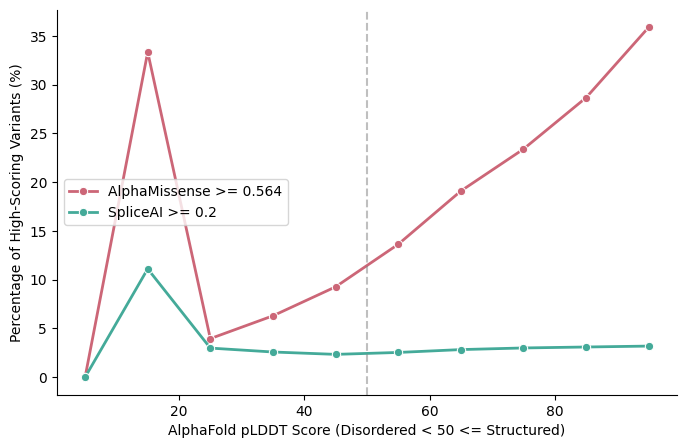

In [22]:
# Create 10-point pLDDT bins
missense_plddt['plddt_bin'] = pd.cut(
    missense_plddt['plddt'], bins=np.arange(0, 101, 10)
)

# Calculate proportions per bin
bin_stats = (
    missense_plddt.groupby('plddt_bin', observed=False)
    .agg(
        total=('Max_SpliceAI_Score', 'count'),
        high_splice=('Max_SpliceAI_Score', lambda x: (x >= 0.2).mean() * 100),
        high_am=(
            'am_pathogenicity',
            lambda x: (x >= 0.564).mean() * 100,
        ),  # Likely pathogenic threshold
    )
    .reset_index()
)

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
bin_stats['bin_mid'] = bin_stats['plddt_bin'].apply(lambda x: x.mid)

sns.lineplot(
    data=bin_stats,
    x='bin_mid',
    y='high_am',
    label='AlphaMissense >= 0.564',
    color='#CC6677',
    marker='o',
    linewidth=2,
)
sns.lineplot(
    data=bin_stats,
    x='bin_mid',
    y='high_splice',
    label='SpliceAI >= 0.2',
    color='#44AA99',
    marker='o',
    linewidth=2,
)

ax.set_xlabel('AlphaFold pLDDT Score (Disordered < 50 <= Structured)')
ax.set_ylabel('Percentage of High-Scoring Variants (%)')
ax.axvline(50, color='grey', linestyle='--', alpha=0.5)
sns.despine()
plt.show()

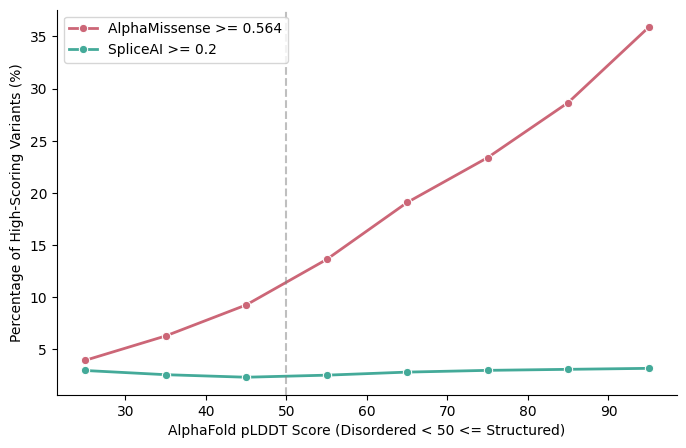

In [24]:
# Create 10-point pLDDT bins
missense_plddt['plddt_bin'] = pd.cut(
    missense_plddt['plddt'], bins=np.arange(0, 101, 10)
)

# Calculate proportions per bin
bin_stats = (
    missense_plddt.groupby('plddt_bin', observed=False)
    .agg(
        total=('Max_SpliceAI_Score', 'count'),
        high_splice=('Max_SpliceAI_Score', lambda x: (x >= 0.2).mean() * 100),
        high_am=(
            'am_pathogenicity',
            lambda x: (x >= 0.564).mean() * 100,
        ),  # Likely pathogenic threshold
    )
    .reset_index()
)

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
bin_stats['bin_mid'] = bin_stats['plddt_bin'].apply(lambda x: x.mid)

sns.lineplot(
    data=bin_stats[bin_stats['bin_mid'] > 15],
    x='bin_mid',
    y='high_am',
    label='AlphaMissense >= 0.564',
    color='#CC6677',
    marker='o',
    linewidth=2,
)
sns.lineplot(
    data=bin_stats[bin_stats['bin_mid'] > 15],
    x='bin_mid',
    y='high_splice',
    label='SpliceAI >= 0.2',
    color='#44AA99',
    marker='o',
    linewidth=2,
)

ax.set_xlabel('AlphaFold pLDDT Score (Disordered < 50 <= Structured)')
ax.set_ylabel('Percentage of High-Scoring Variants (%)')
ax.axvline(50, color='grey', linestyle='--', alpha=0.5)
sns.despine()
plt.show()

In [98]:
bin_stats

,plddt_bin,total,high_splice,high_am,bin_mid
0,"(0, 10]",7,0.000000,0.000000,5.0
1,"(10, 20]",9,11.111111,33.333333,15.0
2,"(20, 30]",5256,2.987062,3.957382,25.0
3,"(30, 40]",61841,2.585663,6.296793,35.0
4,"(40, 50]",209144,2.342405,9.265865,45.0
5,"(50, 60]",273058,2.539387,13.628240,55.0
6,"(60, 70]",264077,2.832886,19.089129,65.0
7,"(70, 80]",402047,3.000395,23.389554,75.0
8,"(80, 90]",1036770,3.098759,28.663927,85.0
9,"(90, 100]",2236967,3.193163,35.881799,95.0


In [105]:
missense_plddt[missense_plddt['plddt_bin'].astype(str) == '(10, 20]']

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8,LMSV,High_Missense,plddt_bin
665477,chr1-197347398-C-A,CRB1,0.00,0.534,0.1353,19.62,True,SpliceAI_DS_AG,-58.0,303,58,+,P82279,-0.015343,False,0,0,0,False,False,"(10, 20]"
665478,chr1-197347401-C-A,CRB1,0.00,0.131,0.0889,10.37,True,SpliceAI_DS_AG,-26.0,304,61,+,P82279,2.089750,False,0,0,0,False,False,"(10, 20]"
967657,chr2-54644459-A-T,SPTBN1,0.00,0.301,0.8707,17.71,True,SpliceAI_DS_AG,20.0,1381,127,+,Q01082,-0.054271,False,0,0,0,False,False,"(10, 20]"
2847527,chr6-75175038-C-T,COL12A1,0.68,0.211,0.0967,10.60,True,SpliceAI_DS_DL,0.0,904,0,-,Q99715,-0.006238,True,1,1,0,True,False,"(10, 20]"
3047395,chr7-4077178-G-C,SDK1,0.01,0.528,0.5048,14.38,True,SpliceAI_DS_AG,3.0,1064,11,+,Q7Z5N4,3.341270,False,0,0,0,False,False,"(10, 20]"
3047396,chr7-4077181-T-C,SDK1,0.00,0.350,0.5932,16.83,True,SpliceAI_DS_AG,-183.0,1065,8,+,Q7Z5N4,-0.124354,False,0,0,0,False,False,"(10, 20]"
3366649,chr7-140674053-C-G,ADCK2,0.00,0.018,0.2926,19.73,True,SpliceAI_DS_AG,143.0,241,210,+,Q7Z695,0.026510,False,0,0,0,False,False,"(10, 20]"
3772122,chr9-18681944-T-A,ADAMTSL1,0.03,0.934,0.9925,13.69,True,SpliceAI_DS_AG,-132.0,492,15,+,Q8N6G6,-0.541925,False,0,0,0,False,False,"(10, 20]"
7263685,chr19-23662149-G-C,ZNF675,0.00,0.005,0.1088,19.54,True,SpliceAI_DS_AG,-222.0,64,35,-,Q8TD23,0.119540,False,0,0,0,False,False,"(10, 20]"


In [102]:
missense_plddt['plddt_bin'].dtype

CategoricalDtype(categories=[  (0, 10],  (10, 20],  (20, 30],  (30, 40],  (40, 50],
                   (50, 60],  (60, 70],  (70, 80],  (80, 90], (90, 100]],
, ordered=True, categories_dtype=interval[int64, right])

In [23]:
disordered = missense_plddt[missense_plddt['Disordered'] == True].copy()
structured = missense_plddt[missense_plddt['Disordered'] == False].copy()

In [108]:
len(disordered[(disordered['Max_SpliceAI_Score'] >= 0.2) & (disordered['REVEL'] < 0.5) & (disordered['am_pathogenicity'] < 0.34)])

5339

In [109]:
len(disordered[disordered['LMSV'] == True])

5339

In [110]:
len(disordered[disordered['Max_SpliceAI_Score'] > 0.2])

6265

In [1]:
# All predicted spliceogenic missense variants in disordered regions
# minus the number of LMSVs, to find High Missense High Splice variants
6265 - 5339

926

In [113]:
5339 / 6265 * 100

85.219473264166

85% of predicted splice disrupting missense variants in IDRs are LMSVs.

In [111]:
len(structured[structured['LMSV'] == True])

65476

In [112]:
len(structured[structured['Max_SpliceAI_Score'] > 0.2])

122289

In [9]:
# All predicted spliceogenic missense variants in structured regions
# minus the number of LMSVs, to find High Missense High Splice variants
122289 - 65476

56813

In [10]:
# Testing if predicted splice Missense Variants in IDRs are Enriched for LMSVs
contingency = [
    [5339,926],
    [65476, 56813]
    ]

odds_ratio, p_value = fisher_exact(contingency)
print(f'Odds Ratio: {odds_ratio}, p_value: {p_value}')

Odds Ratio: 5.0028158471862545, p_value: 0.0


In [114]:
65476 / 122289 * 100

53.54201931490159

54% of predicted splice disrupting missense variants in structured regions are LMSVs.

In [115]:
len(disordered)

276002

In [117]:
276002 - 5339

270663

In [118]:
4213174 - 65476

4147698

In [116]:
len(structured)

4213174

In [3]:
# Testing if Missense Variants in IDRs are Enriched for LMSVs
contingency = [
    [5339,65476],
    [270663, 4147698]
    ]

odds_ratio, p_value = fisher_exact(contingency)
print(f'Odds Ratio: {odds_ratio}, p_value: {p_value}')

Odds Ratio: 1.2495568421306582, p_value: 3.5333723462120843e-51


In [7]:
# Testing if missense splice disruption is independent of pLDDT
contingency = [
    [6650,269352],
    [130041, 4083133]
    ]

odds_ratio, p_value = fisher_exact(contingency)
print(f'Odds Ratio: {odds_ratio}, p_value: {p_value}')

Odds Ratio: 0.7752016110380643, p_value: 1.358546636837398e-95


IDRs have slightly lower splice-disrupting missense variants frequency (2.41%) than structured regions surprisingly (3.09%), however, when a splice disruption does occur in an IDR, protein-centric tools are 5x more likely to miss it in an IDR compared to a structured region, with 85.22% of predicted splice-disrupting variants in IDRs being LMSVs compared to 54% in structured regions. 

# Is Reduced Spliceogenicity in IDRs Driven By Protein Terminals?

In [29]:
missense_plddt.sample()

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8,LMSV,High_Missense,plddt_bin
4077303,chr9-137452428-T-C,NSMF,0.22,0.248,0.1774,98.02,False,SpliceAI_DS_AG,5.0,391,7,-,Q6X4W1,-0.052511,True,1,0,0,True,False,"(90, 100]"


In [34]:
missense_plddt['plddt_bin'] = missense_plddt['plddt_bin'].astype(str)
missense_plddt.to_parquet('/slade/home/mr935/data/biobank_data/missense_plddt.parquet')

In [34]:
missense_plddt = pd.read_parquet('/slade/home/mr935/data/biobank_data/missense_plddt.parquet', engine='pyarrow')

In [35]:
missense_plddt['plddt_bin'] = missense_plddt['plddt_bin'].astype('category')

In [7]:
# Group by UniProt Accession, and filter out residues 
# in first/last 15% of residues in protein
missense_plddt = missense_plddt.sort_values(['uniprot_accession', 'Protein_position']).reset_index(drop=True)
missense_plddt.head(10)

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8,LMSV,High_Missense,plddt_bin
0,chr1-152843524-T-C,LCE6A,0.00,0.121,0.1442,72.14,False,SpliceAI_DS_AG,-24.0,2,24,+,A0A183,1.834970,False,0,0,0,False,False,"(70, 80]"
1,chr1-152843527-C-G,LCE6A,0.01,0.111,0.0948,77.78,False,SpliceAI_DS_AG,363.0,3,27,+,A0A183,-0.200173,False,0,0,0,False,False,"(70, 80]"
2,chr1-152843528-A-C,LCE6A,0.00,0.094,0.1384,77.78,False,SpliceAI_DS_AG,-28.0,3,28,+,A0A183,0.698766,False,0,0,0,False,False,"(70, 80]"
3,chr1-152843535-G-T,LCE6A,0.03,0.088,0.3491,72.73,False,SpliceAI_DS_AL,-35.0,5,35,+,A0A183,0.404412,False,0,0,0,False,False,"(70, 80]"
4,chr1-152843542-T-C,LCE6A,0.00,0.027,0.0877,70.89,False,SpliceAI_DS_AG,-42.0,8,42,+,A0A183,-0.469057,False,0,0,0,False,False,"(70, 80]"
5,chr1-152843543-C-T,LCE6A,0.01,0.049,0.1585,70.89,False,SpliceAI_DS_AG,411.0,8,43,+,A0A183,-0.755327,False,0,0,0,False,False,"(70, 80]"
6,chr1-152843554-C-T,LCE6A,0.00,0.106,0.0863,75.44,False,SpliceAI_DS_AG,-54.0,12,54,+,A0A183,1.206700,False,0,0,0,False,False,"(70, 80]"
7,chr1-152843555-C-T,LCE6A,0.03,0.111,0.1207,75.44,False,SpliceAI_DS_AL,-55.0,12,55,+,A0A183,1.043190,False,0,0,0,False,False,"(70, 80]"
8,chr1-152843557-A-G,LCE6A,0.00,0.074,0.0791,72.06,False,SpliceAI_DS_AG,-57.0,13,57,+,A0A183,-0.380352,False,0,0,0,False,False,"(70, 80]"
9,chr1-152843558-A-G,LCE6A,0.00,0.093,0.0779,72.06,False,SpliceAI_DS_AG,-58.0,13,58,+,A0A183,0.294538,False,0,0,0,False,False,"(70, 80]"


In [36]:
protein_bounds = missense_plddt.groupby('uniprot_accession')['Protein_position'].agg(
    pos_min='min',
    pos_max='max'
).reset_index()

In [9]:
protein_bounds.head()

,uniprot_accession,pos_min,pos_max
0,A0A183,2,80
1,A0A1B0GVR7,2,94
2,A0AUZ9,217,938
3,A0AV02,2,712
4,A0AV96,26,334


In [37]:
protein_bounds['l_bound'] = (np.ceil(protein_bounds['pos_max'] * 0.25)).astype(int)
protein_bounds['u_bound'] = (protein_bounds['pos_max'] - np.ceil(protein_bounds['pos_max'] * 0.25)).astype(int)

In [20]:
protein_bounds.head()

,uniprot_accession,pos_min,pos_max,l_bound,u_bound
0,A0A183,2,80,12,68
1,A0A1B0GVR7,2,94,15,79
2,A0AUZ9,217,938,141,797
3,A0AV02,2,712,107,605
4,A0AV96,26,334,51,283


In [38]:
missense_plddt = missense_plddt.merge(
    protein_bounds[['uniprot_accession', 'l_bound', 'u_bound']],
    on='uniprot_accession'
)

In [23]:
missense_plddt.sample(5)

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8,LMSV,High_Missense,plddt_bin,l_bound,u_bound
2793833,chr4-146909092-C-T,TTC29,0.0,0.073,0.1166,84.48,False,SpliceAI_DS_AG,9.0,112,66,-,Q8NA56,-0.217101,False,0,0,0,False,False,"(80, 90]",68,382
1420788,chr1-21862048-G-A,HSPG2,0.0,0.453,0.4605,86.43,False,SpliceAI_DS_AG,67.0,1603,60,-,P98160,1.307090,False,0,0,0,False,False,"(80, 90]",659,3732
2007853,chr1-204410048-T-G,PPP1R15B,0.0,0.118,0.2696,57.07,False,SpliceAI_DS_AG,445.0,455,556,-,Q5SWA1,-0.100212,False,0,0,0,False,False,"(50, 60]",107,606
192884,chr17-4780796-G-A,TM4SF5,0.0,0.322,0.7518,91.52,False,SpliceAI_DS_AG,-7.0,62,7,+,O14894,-0.835763,False,0,0,0,False,False,"(90, 100]",30,167
3982288,chr3-108218608-C-T,IFT57,0.0,0.822,0.9656,86.64,False,SpliceAI_DS_AG,40.0,141,45,-,Q9NWB7,4.107010,False,0,0,0,False,False,"(80, 90]",65,362


In [39]:
cent_mis_plddt = missense_plddt[
    (missense_plddt['Protein_position'] >= missense_plddt['l_bound']) &
    (missense_plddt['Protein_position'] <= missense_plddt['u_bound'])
].drop(columns=['l_bound', 'u_bound']).reset_index(drop=True)

In [26]:
cent_mis_plddt.head()

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8,LMSV,High_Missense,plddt_bin
0,chr1-152843554-C-T,LCE6A,0.00,0.106,0.0863,75.44,False,SpliceAI_DS_AG,-54.0,12,54,+,A0A183,1.206700,False,0,0,0,False,False,"(70, 80]"
1,chr1-152843555-C-T,LCE6A,0.03,0.111,0.1207,75.44,False,SpliceAI_DS_AL,-55.0,12,55,+,A0A183,1.043190,False,0,0,0,False,False,"(70, 80]"
2,chr1-152843557-A-G,LCE6A,0.00,0.074,0.0791,72.06,False,SpliceAI_DS_AG,-57.0,13,57,+,A0A183,-0.380352,False,0,0,0,False,False,"(70, 80]"
3,chr1-152843558-A-G,LCE6A,0.00,0.093,0.0779,72.06,False,SpliceAI_DS_AG,-58.0,13,58,+,A0A183,0.294538,False,0,0,0,False,False,"(70, 80]"
4,chr1-152843561-T-C,LCE6A,0.00,0.059,0.0815,71.87,False,SpliceAI_DS_AG,-61.0,14,61,+,A0A183,0.049769,False,0,0,0,False,False,"(70, 80]"


In [27]:
len(missense_plddt)

4489176

In [40]:
len(cent_mis_plddt)

2251148

In [31]:
summary = missense_plddt.groupby(
    'Disordered')['High_Splice'].agg(
        Total_Variants='count',
        High_Splice_True='sum',
        Percentage_High_Splice=lambda x: x.mean() * 100
    ).reset_index()

summary

,Disordered,Total_Variants,High_Splice_True,Percentage_High_Splice
0,False,4213174,130041,3.086533
1,True,276002,6650,2.409403


In [29]:
# 15% cutoff
summary = cent_mis_plddt.groupby(
    'Disordered')['High_Splice'].agg(
        Total_Variants='count',
        High_Splice_True='sum',
        Percentage_High_Splice=lambda x: x.mean() * 100
    ).reset_index()

summary

,Disordered,Total_Variants,High_Splice_True,Percentage_High_Splice
0,False,2999264,98301,3.277504
1,True,156696,4098,2.615255


In [41]:
# 25% cutoff
summary = cent_mis_plddt.groupby(
    'Disordered')['High_Splice'].agg(
        Total_Variants='count',
        High_Splice_True='sum',
        Percentage_High_Splice=lambda x: x.mean() * 100
    ).reset_index()

summary

,Disordered,Total_Variants,High_Splice_True,Percentage_High_Splice
0,False,2141533,71328,3.330698
1,True,109615,2946,2.687588


In [33]:
# Testing if missense splice disruption is independent of pLDDT
# 15% cutoff
contingency = [
    [4098,156696 - 4098],
    [98301, 2999264 - 98301]
    ]

odds_ratio, p_value = fisher_exact(contingency)
print(f'Odds Ratio: {odds_ratio}, p_value: {p_value}')

Odds Ratio: 0.7925147725111309, p_value: 4.585448113768454e-50


In [42]:
# 25% cutoff
contingency = [
    [2946,109615 - 2946],
    [71328, 2141533 - 71328]
    ]

odds_ratio, p_value = fisher_exact(contingency)
print(f'Odds Ratio: {odds_ratio}, p_value: {p_value}')

Odds Ratio: 0.8015817580155474, p_value: 5.0595571904749976e-33


In [32]:
summary = cent_mis_plddt.groupby(
    'Disordered').agg(
        Total_Variants=('Disordered', 'count'),
        SpliceAI_02 = ('SpliceAI_0.2', lambda x: np.mean(x) * 100),
        SpliceAI_05 = ('SpliceAI_0.5', lambda x: np.mean(x) * 100),
        SpliceAI_08 = ('SpliceAI_0.8', lambda x: np.mean(x) * 100)
    ).reset_index()

summary

,Disordered,Total_Variants,SpliceAI_02,SpliceAI_05,SpliceAI_08
0,False,2999264,3.277504,1.006714,0.383294
1,True,156696,2.615255,0.798999,0.292924


In [30]:
summary = missense_plddt.groupby(
    'Disordered').agg(
        Total_Variants=('Disordered', 'count'),
        SpliceAI_02 = ('SpliceAI_0.2', lambda x: np.mean(x) * 100),
        SpliceAI_05 = ('SpliceAI_0.5', lambda x: np.mean(x) * 100),
        SpliceAI_08 = ('SpliceAI_0.8', lambda x: np.mean(x) * 100)
    ).reset_index()

summary

,Disordered,Total_Variants,SpliceAI_02,SpliceAI_05,SpliceAI_08
0,False,4213174,3.086533,0.950922,0.360797
1,True,276002,2.409403,0.729343,0.269201


Hypothesis was that variants with low pLDDT are more likely to be at the terminal ends of a protein, which is where splice disruption is much less likely to occur. Therefore, the reduced proportion of missense variants predicted to disrupt splicing in disordered regions compared to structured regions may be driven by these confounding factors. Therefore, can we control for this by assessing the same relationship in the centres of a protein, where splice disruption should be more likely to occur.

When limiting analysis to variants within the central 70% of a protein, the OR increases by 0.02. When limiting analysis to variants within the central 50% of a protein, the OR increases by 0.01. This shows that the position of the variant is likely not having an effect on the likelihood of a missense variant being predicted to disrupt splicing in structured regions relative to disordered regions. This then increases the validity of our finding that a higher proportion of variants in structured regions are predicted to disrupt splicing compared to an intrinsically disordered region. 

In [43]:
missense_plddt.head()

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8,LMSV,High_Missense,plddt_bin,l_bound,u_bound
0,chr1-944721-C-A,NOC2L,0.02,0.045,0.1952,34.79,True,SpliceAI_DS_AG,98.0,741,79,-,Q9Y3T9,0.073905,False,0,0,0,False,False,"(30, 40]",186,555
1,chr1-944723-C-G,NOC2L,0.02,0.072,0.0859,34.79,True,SpliceAI_DS_AG,-173.0,741,77,-,Q9Y3T9,-0.157157,False,0,0,0,False,False,"(30, 40]",186,555
2,chr1-944726-G-T,NOC2L,0.00,0.092,0.1553,36.37,True,SpliceAI_DS_AG,93.0,740,74,-,Q9Y3T9,1.717900,False,0,0,0,False,False,"(30, 40]",186,555
3,chr1-944729-C-G,NOC2L,0.01,0.051,0.1037,36.42,True,SpliceAI_DS_AG,-179.0,739,71,-,Q9Y3T9,0.020313,False,0,0,0,False,False,"(30, 40]",186,555
4,chr1-944729-C-T,NOC2L,0.01,0.042,0.0990,36.42,True,SpliceAI_DS_AG,-179.0,739,71,-,Q9Y3T9,-0.391151,False,0,0,0,False,False,"(30, 40]",186,555


In [44]:
len(missense_plddt)

4489176

In [45]:
missense_plddt['Disordered'].sum()

np.int64(276002)

In [46]:
276002 / 4489176 * 100

6.148166166797648

6.15% of missense variants in the UKB with gene symbols matching a uniprot gene symbol, along with a matching uniprot accession number from alphafold, are in disordered regions.

Will check for duplicate residue positions.

In [48]:
missense_plddt['Chrom'] = missense_plddt['variantID'].str.split('-').str[0].str.split('r').str[1]
missense_plddt['Pos'] = missense_plddt['variantID'].str.split('-').str[1]

In [49]:
missense_plddt.head()

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8,LMSV,High_Missense,plddt_bin,l_bound,u_bound,Chrom,Pos
0,chr1-944721-C-A,NOC2L,0.02,0.045,0.1952,34.79,True,SpliceAI_DS_AG,98.0,741,79,-,Q9Y3T9,0.073905,False,0,0,0,False,False,"(30, 40]",186,555,1,944721
1,chr1-944723-C-G,NOC2L,0.02,0.072,0.0859,34.79,True,SpliceAI_DS_AG,-173.0,741,77,-,Q9Y3T9,-0.157157,False,0,0,0,False,False,"(30, 40]",186,555,1,944723
2,chr1-944726-G-T,NOC2L,0.00,0.092,0.1553,36.37,True,SpliceAI_DS_AG,93.0,740,74,-,Q9Y3T9,1.717900,False,0,0,0,False,False,"(30, 40]",186,555,1,944726
3,chr1-944729-C-G,NOC2L,0.01,0.051,0.1037,36.42,True,SpliceAI_DS_AG,-179.0,739,71,-,Q9Y3T9,0.020313,False,0,0,0,False,False,"(30, 40]",186,555,1,944729
4,chr1-944729-C-T,NOC2L,0.01,0.042,0.0990,36.42,True,SpliceAI_DS_AG,-179.0,739,71,-,Q9Y3T9,-0.391151,False,0,0,0,False,False,"(30, 40]",186,555,1,944729


In [50]:
missense_res = missense_plddt.drop_duplicates(['uniprot_accession', 'Protein_position']).copy()
missense_res.head()

,variantID,SYMBOL,Max_SpliceAI_Score,REVEL,am_pathogenicity,plddt,Disordered,Max_SpliceAI_Column,Max_SpliceAI_Position,Protein_position,Variant_Canonical_Splice_Distance,Strand,uniprot_accession,foldx_ddg,High_Splice,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8,LMSV,High_Missense,plddt_bin,l_bound,u_bound,Chrom,Pos
0,chr1-944721-C-A,NOC2L,0.02,0.045,0.1952,34.79,True,SpliceAI_DS_AG,98.0,741,79,-,Q9Y3T9,0.073905,False,0,0,0,False,False,"(30, 40]",186,555,1,944721
2,chr1-944726-G-T,NOC2L,0.00,0.092,0.1553,36.37,True,SpliceAI_DS_AG,93.0,740,74,-,Q9Y3T9,1.717900,False,0,0,0,False,False,"(30, 40]",186,555,1,944726
3,chr1-944729-C-G,NOC2L,0.01,0.051,0.1037,36.42,True,SpliceAI_DS_AG,-179.0,739,71,-,Q9Y3T9,0.020313,False,0,0,0,False,False,"(30, 40]",186,555,1,944729
5,chr1-944730-G-C,NOC2L,0.02,0.078,0.4592,45.94,True,SpliceAI_DS_AG,-180.0,738,70,-,Q9Y3T9,1.293590,False,0,0,0,False,False,"(40, 50]",186,555,1,944730
8,chr1-944734-T-C,NOC2L,0.17,0.099,0.0917,44.56,True,SpliceAI_DS_AG,-184.0,737,66,-,Q9Y3T9,0.680717,False,0,0,0,False,False,"(40, 50]",186,555,1,944734


In [51]:
len(missense_res)

3154276

In [52]:
len(missense_plddt)

4489176

In [53]:
# No duplicate residues
summary = missense_res.groupby(
    'Disordered')['High_Splice'].agg(
        Total_Variants='count',
        High_Splice_True='sum',
        Percentage_High_Splice=lambda x: x.mean() * 100
    ).reset_index()

summary

,Disordered,Total_Variants,High_Splice_True,Percentage_High_Splice
0,False,2967678,92034,3.101212
1,True,186598,4647,2.490380


In [54]:
186598 / 3154276 * 100

5.915715682457718

5.92% of missense variants in the UKB with gene symbols matching a uniprot gene symbol, along with a matching uniprot accession number from alphafold, are in disordered regions.